<a href="https://colab.research.google.com/github/col38470682/GVH-Dynamique/blob/main/notebooks/GVH_GravityTrain_Benchmark_0.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GVH Gravity-Train Benchmark 0.1 :

\boxed{
\text{solution analytique}
\rightarrow
\text{simulation numérique}
\rightarrow
\text{observables GVH}
}

Étape 1 — Objectif du notebook

Dans une Terre homogène idéale :

\ddot{x}=-\omega^2 x

avec :

\omega=\sqrt{\frac{g}{R_\oplus}}

et

x(t)=R_\oplus\cos(\omega t)

Le trajet surface → surface dure :

T=\frac{\pi}{\omega}
=
\pi\sqrt{\frac{R_\oplus}{g}}
\approx 42\ \text{minutes}

Étape 2 — Cellule titre

# GVH Gravity-Train Benchmark 0.1

## Objectif

Ce notebook compare une solution analytique connue à une simulation numérique RK4 pour le problème idéal du tunnel gravitationnel à travers une Terre homogène.

La chaîne testée est :

\[
\text{solution analytique}
\rightarrow
\text{simulation numérique}
\rightarrow
\text{observables GVH}
\]

Cette version constitue un benchmark analytique pour GVH Dynamic.

Étape 3 — Imports Python

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Étape 4 — Constantes physiques

In [5]:
# Constantes physiques
R_earth = 6.371e6      # rayon terrestre en mètres
g = 9.81              # gravité de surface en m/s^2

omega = np.sqrt(g / R_earth)

T_cross = np.pi / omega      # demi-période : surface à surface
T_full = 2 * np.pi / omega   # période complète

print("omega =", omega)
print("Temps surface -> surface =", T_cross / 60, "minutes")
print("Période complète =", T_full / 60, "minutes")

omega = 0.001240882618119469
Temps surface -> surface = 42.19567330162151 minutes
Période complète = 84.39134660324302 minutes


Étape 5 — Solution analytique

In [3]:
# Temps
N = 5000
t = np.linspace(0, T_cross, N)

# Solution analytique
x_analytic = R_earth * np.cos(omega * t)
v_analytic = -R_earth * omega * np.sin(omega * t)
a_analytic = -omega**2 * x_analytic

df_analytic = pd.DataFrame({
    "t": t,
    "x": x_analytic,
    "v": v_analytic,
    "a": a_analytic
})

df_analytic.head()

,t,x,v,a
0,0.000000,6.371000e+06,-0.000000,-9.810000
1,0.506449,6.370999e+06,-4.968268,-9.809998
2,1.012899,6.370995e+06,-9.936534,-9.809992
3,1.519348,6.370989e+06,-14.904796,-9.809983
4,2.025797,6.370980e+06,-19.873052,-9.809969


Étape 6 — Simulation numérique RK4

In [4]:
def gravity_train_deriv(state):
    x, v = state
    dxdt = v
    dvdt = -omega**2 * x
    return np.array([dxdt, dvdt])

def rk4_step(state, dt):
    k1 = gravity_train_deriv(state)
    k2 = gravity_train_deriv(state + 0.5 * dt * k1)
    k3 = gravity_train_deriv(state + 0.5 * dt * k2)
    k4 = gravity_train_deriv(state + dt * k3)
    return state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

dt = t[1] - t[0]

state = np.array([R_earth, 0.0])
states = []

for _ in range(N):
    states.append(state.copy())
    state = rk4_step(state, dt)

states = np.array(states)

x_num = states[:, 0]
v_num = states[:, 1]
a_num = -omega**2 * x_num

df_num = pd.DataFrame({
    "t": t,
    "x": x_num,
    "v": v_num,
    "a": a_num
})

df_num.head()

,t,x,v,a
0,0.000000,6.371000e+06,0.000000,-9.810000
1,0.506449,6.370999e+06,-4.968268,-9.809998
2,1.012899,6.370995e+06,-9.936534,-9.809992
3,1.519348,6.370989e+06,-14.904796,-9.809983
4,2.025797,6.370980e+06,-19.873052,-9.809969


Étape 7 — Comparaison analytique vs numérique

In [6]:
error_x = np.abs(x_analytic - x_num)
error_v = np.abs(v_analytic - v_num)

print("Erreur max sur x :", error_x.max())
print("Erreur max sur v :", error_v.max())

Erreur max sur x : 1.30385160446167e-08
Erreur max sur v : 2.864908310584724e-11


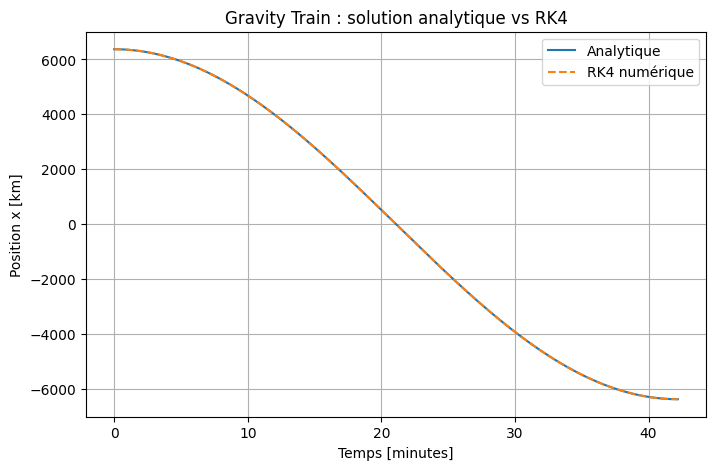

In [9]:
plt.figure(figsize=(8,5))
plt.plot(t/60, x_analytic/1000, label="Analytique")
plt.plot(t/60, x_num/1000, "--", label="RK4 numérique")
plt.xlabel("Temps [minutes]")
plt.ylabel("Position x [km]")
plt.title("Gravity Train : solution analytique vs RK4")
plt.legend()
plt.grid(True)
plt.show()

# Observables GVH

Nous appliquons maintenant le noyau GVH Dynamic à la trajectoire validée.

Chaque état dynamique est défini par :

\[
X(t) = (x(t), v(t), a(t)).
\]

La distance locale est :

\[
D_T(i)=\|X_{i+1}-X_i\|.
\]

Les observables calculées sont :

\[
D_T^{mean},\quad S_T,\quad S_T^{norm},\quad D_c,\quad R_{\rm super}.
\]

In [12]:
def compute_gvh_observables(df):
    X = df[["x", "v", "a"]].values

    dX = np.diff(X, axis=0)
    D_T = np.linalg.norm(dX, axis=1)

    D_T_mean = np.mean(D_T)
    S_T = np.std(D_T)
    S_T_norm = S_T / D_T_mean if D_T_mean != 0 else np.nan

    D_c = np.quantile(D_T, 0.90)
    R_super = np.mean(D_T > D_c)

    return D_T, {
        "D_T_mean": D_T_mean,
        "S_T": S_T,
        "S_T_norm": S_T_norm,
        "D_c": D_c,
        "R_super": R_super
    }

D_T_analytic, obs_analytic = compute_gvh_observables(df_analytic)
D_T_num, obs_num = compute_gvh_observables(df_num)

obs_table = pd.DataFrame([
    {"Model": "Analytique", **obs_analytic},
    {"Model": "RK4 numérique", **obs_num}
])

obs_table

,Model,D_T_mean,S_T,S_T_norm,D_c,R_super
0,Analytique,2548.924611,1232.183097,0.483413,3954.504806,0.09982
1,RK4 numérique,2548.924611,1232.183097,0.483413,3954.504806,0.09982


## Validation analytique-numérique

La solution RK4 reproduit la solution analytique avec une erreur maximale :

\[
\Delta x_{\max}\approx 1.3\times 10^{-8}\ \mathrm{m}
\]

\[
\Delta v_{\max}\approx 2.9\times 10^{-11}\ \mathrm{m/s}
\]

Ces écarts sont négligeables devant les échelles physiques du problème :

\[
R_\oplus \approx 6.37\times 10^6\ \mathrm{m}
\]

et

\[
v_{\max}\approx 7.9\times 10^3\ \mathrm{m/s}.
\]

Le module analytique-numérique du benchmark GVH Gravity-Train 0.1 est donc validé.